In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from models import EEGNet

In [36]:
data = np.load("recordings/open.npz")
stream_key = list(data.keys())[0]
raw_data = data[stream_key]

In [37]:
X = raw_data.reshape(1, 1, *raw_data.shape[::-1])
X

array([[[[ -12782.87207031, -187500.015625  , -112193.65625   , ...,
           187499.984375  ,  178423.484375  ,   14254.17578125],
         [ 129699.1875    ,  187499.984375  ,  184694.125     , ...,
          -160901.125     , -187500.015625  , -187500.015625  ],
         [ -11541.56835938, -166093.4375    , -120278.953125  , ...,
           113724.0625    ,   31946.296875  ,   30223.75976562],
         ...,
         [ 125308.609375  ,  187499.984375  ,  178136.265625  , ...,
          -181815.765625  , -187500.015625  , -187500.015625  ],
         [   3728.91894531, -187500.015625  , -121608.3046875 , ...,
          -114983.1328125 ,   78702.1171875 ,   78716.4921875 ],
         [-187500.015625  , -140191.140625  , -160462.203125  , ...,
           187499.984375  ,  177415.84375   ,  131390.46875   ]]]],
      shape=(1, 1, 8, 5500))

In [29]:
X.shape

(1, 1, 8, 2500)

In [38]:
# Raw values
VREF = 4.5                       # ADS1299 Internal Reference
GAIN = 24.0                   # Matches ADS1299_PGA_GAIN_24

# Scale factor to convert 24-bit raw counts to Microvolts
SCALE_FACTOR_UV = (2.0 * VREF / GAIN) / (2**24 - 1) * 1000000.0

X = X / SCALE_FACTOR_UV

In [39]:
X.shape

(1, 1, 8, 5500)

In [40]:
import numpy as np
from scipy.signal import butter, iirnotch, sosfiltfilt, filtfilt

# -------------------------
# Parameters
# -------------------------
fs = 250
lowcut = 4.0
highcut = 38.0
notch_freq = 50.0
quality = 10.0    # Notch filter Q factor

# -------------------------
# Design filters
# -------------------------
# 4th-order Butterworth bandpass
sos = butter(
    N=6,
    Wn=[lowcut, highcut],
    btype="bandpass",
    fs=fs,
    output="sos"
)

# Notch filter
b_notch, a_notch = iirnotch(
    w0=notch_freq,
    Q=quality,
    fs=fs
)

# -------------------------
# Apply filters
# -------------------------
# Filter along the time axis (axis=1)
X_filtered = sosfiltfilt(sos, X, axis=-1)
X_filtered = filtfilt(b_notch, a_notch, X_filtered, axis=-1)


print(X_filtered.shape)

(1, 1, 8, 5500)


In [33]:
# Useful signal metrics to analyse weird behaviour => signals looks normal and suddenly spikes outside normal range.
# Print out useful data to describe each of signal's 6 different samples for each of the 8 channels
# Task: print out the data
for i in range(8):
    print(f"Channel {i+1}:")
    for j in range(6):
        signal = X_filtered[j, :, i, :]
        print(f"  Sample {j+1}:")
        print(f"    Mean: {np.mean(signal):.4f}")
        print(f"    Std Dev: {np.std(signal):.4f}")
        print(f"    Min: {np.min(signal):.4f}")
        print(f"    Max: {np.max(signal):.4f}")
        print(f"    Median: {np.median(signal):.4f}")
        print(f"    25th Percentile: {np.percentile(signal, 25):.4f}")
        print(f"    75th Percentile: {np.percentile(signal, 75):.4f}")

Channel 1:
  Sample 1:
    Mean: -20353.4895
    Std Dev: 1929562.9542
    Min: -6000572.2707
    Max: 3653816.9535
    Median: -496055.8032
    25th Percentile: -2069314.4516
    75th Percentile: 1594608.9268


IndexError: index 1 is out of bounds for axis 0 with size 1

In [34]:
print("Raw counts (but after filtering) without a spike")
print(X_filtered[1, 0, 0, 0:100]/SCALE_FACTOR_UV)

print("Raw counts (but after filtering) during a spike")
print(X_filtered[1, 0, 0, 800:]/SCALE_FACTOR_UV)


print("Raw counts (without filtering) without a spike")
print(X[1, 0, 0, 0:100]/SCALE_FACTOR_UV)

print("Raw counts (without filtering) during a spike")
print(X[1, 0, 0, 800:]/SCALE_FACTOR_UV)

Raw counts (but after filtering) without a spike


IndexError: index 1 is out of bounds for axis 0 with size 1

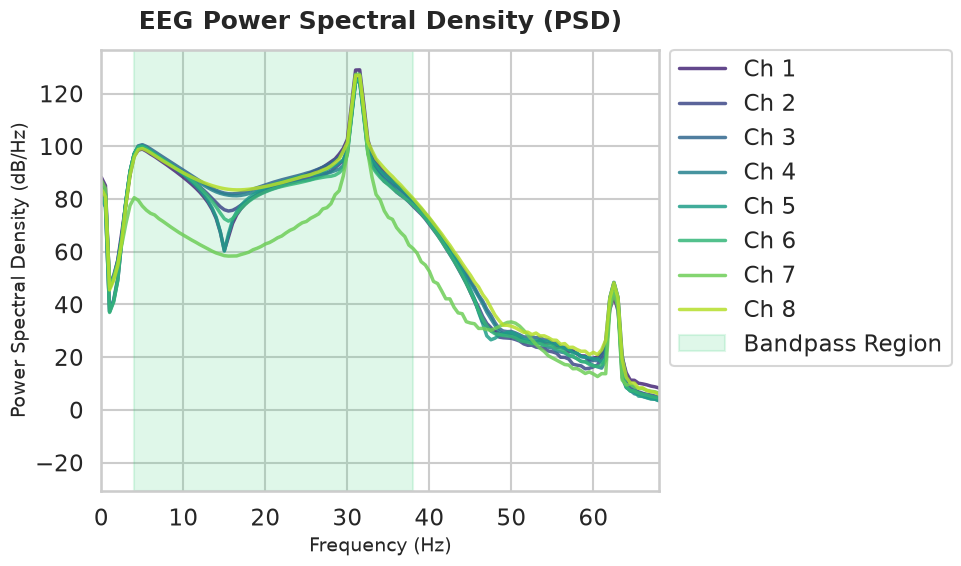

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import welch

# Ensure a clean plotting style
sns.set_theme(style="whitegrid", context="talk")

# -----------------------------------------------------------------
# 1. Compute PSD using Welch's Method
# -----------------------------------------------------------------
# Set segment length to 2 seconds for a clean 0.5 Hz resolution
nperseg = min(2 * fs, X_filtered.shape[-1])

# welch automatically operates along the last axis (axis=-1, time)
freqs, psd_raw = welch(X_filtered, fs=fs, nperseg=nperseg)
# psd_raw shape will be: (3, 1, 8, freqs_length)

# -----------------------------------------------------------------
# 2. Average Across Batches and Trials (Dimensions 0 and 1)
# -----------------------------------------------------------------
# Average over axis 0 and axis 1 to get a (8, freqs_length) matrix
psd_averaged = np.mean(psd_raw, axis=(0, 1))
num_channels = psd_averaged.shape[0]

# Convert power to decibels (dB) for standard EEG visualization
psd_db = 10 * np.log10(psd_averaged)

# -----------------------------------------------------------------
# 3. Create a Beautiful Plot
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=100)

# Use a distinct color palette for the 8 EEG channels
colors = sns.color_palette("viridis", n_colors=num_channels)

for i in range(num_channels):
    plt.plot(
        freqs,
        psd_db[i],
        label=f"Ch {i+1}",
        color=colors[i],
        linewidth=2.5,
        alpha=0.85,
    )

# Highlight your filter bandpass region (8.0 - 30.0 Hz)
# Highlight your filter bandpass region (8.0 - 30.0 Hz)
plt.axvspan(
    lowcut,
    highcut,
    color="#2ecc71",     # Hex code for the same green
    alpha=0.15,          # Transparency set separately
    label="Bandpass Region",
)


# Custom formatting
plt.title("EEG Power Spectral Density (PSD)",
          fontsize=18, pad=15, weight="bold")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Power Spectral Density (dB/Hz)", fontsize=14)

# Restrict X-axis slightly past your highcut filter to focus on relevant data
plt.xlim(0, highcut + 30)

# Clean up layout
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


Channel    | Alpha Relative Power (%)  | Beta Relative Power (%)  
--------------------------------------------------------------------
Ch 1       | 73.60                     | 25.76                    
Ch 2       | 64.96                     | 33.01                    
Ch 3       | 56.47                     | 42.31                    
Ch 4       | 74.56                     | 23.76                    
Ch 5       | 78.04                     | 17.43                    
Ch 6       | 32.33                     | 59.36                    
Ch 7       | 50.36                     | 48.34                    
Ch 8       | 48.54                     | 50.73                    


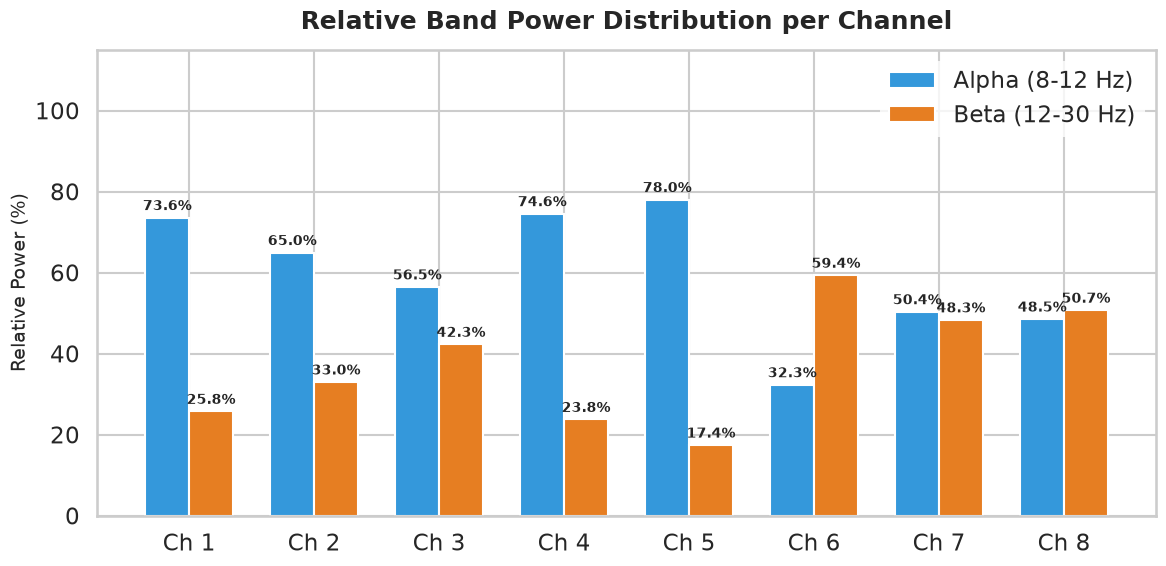

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure a clean plotting style
sns.set_theme(style="whitegrid", context="talk")

# 1. Define your target frequency bands
bands = {"Alpha": (8.0, 12.0), "Beta": (12.0, 30.0)}

# 2. Compute the total power across the entire spectrum for each channel
# CHANGED: np.trapz -> np.trapezoid for NumPy 2.0 compliance
total_power = np.trapezoid(psd_averaged, freqs, axis=-1)
relative_powers = {}

# 3. Integrate power inside each band and divide by total power
for band_name, (f_start, f_end) in bands.items():
    band_mask = (freqs >= f_start) & (freqs <= f_end)
    band_freqs = freqs[band_mask]
    band_psd = psd_averaged[:, band_mask]

    # CHANGED: np.trapz -> np.trapezoid
    band_power = np.trapezoid(band_psd, band_freqs, axis=-1)
    relative_powers[band_name] = band_power / total_power

# -----------------------------------------------------------------
# 4. Print the Results Beautifully
# -----------------------------------------------------------------
print(
    f"{'Channel':<10} | {'Alpha Relative Power (%)':<25} | {'Beta Relative Power (%)':<25}"
)
print("-" * 68)

num_channels = psd_averaged.shape[0]
for ch in range(num_channels):
    alpha_pct = relative_powers["Alpha"][ch] * 100
    beta_pct = relative_powers["Beta"][ch] * 100
    print(f"Ch {ch+1:<7} | {alpha_pct:<25.2f} | {beta_pct:<25.2f}")

# -----------------------------------------------------------------
# 5. Create a Beautiful Bar Chart for Relative Power
# -----------------------------------------------------------------
channels = [f"Ch {i+1}" for i in range(num_channels)]
alpha_data = relative_powers["Alpha"] * 100
beta_data = relative_powers["Beta"] * 100

x = np.arange(num_channels)  # The label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Plot Alpha and Beta bars side-by-side using professional colors
rects1 = ax.bar(
    x - width / 2, alpha_data, width, label="Alpha (8-12 Hz)", color="#3498db"
)
rects2 = ax.bar(
    x + width / 2, beta_data, width, label="Beta (12-30 Hz)", color="#e67e22"
)

# Custom formatting
ax.set_ylabel("Relative Power (%)", fontsize=14)
ax.set_title(
    "Relative Band Power Distribution per Channel",
    fontsize=18,
    pad=15,
    weight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.set_ylim(0, 115)  # Slight padding at top for labels
ax.legend(frameon=True, facecolor="white", edgecolor="none")


# Add value labels on top of the bars for scannability
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="semibold",
        )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

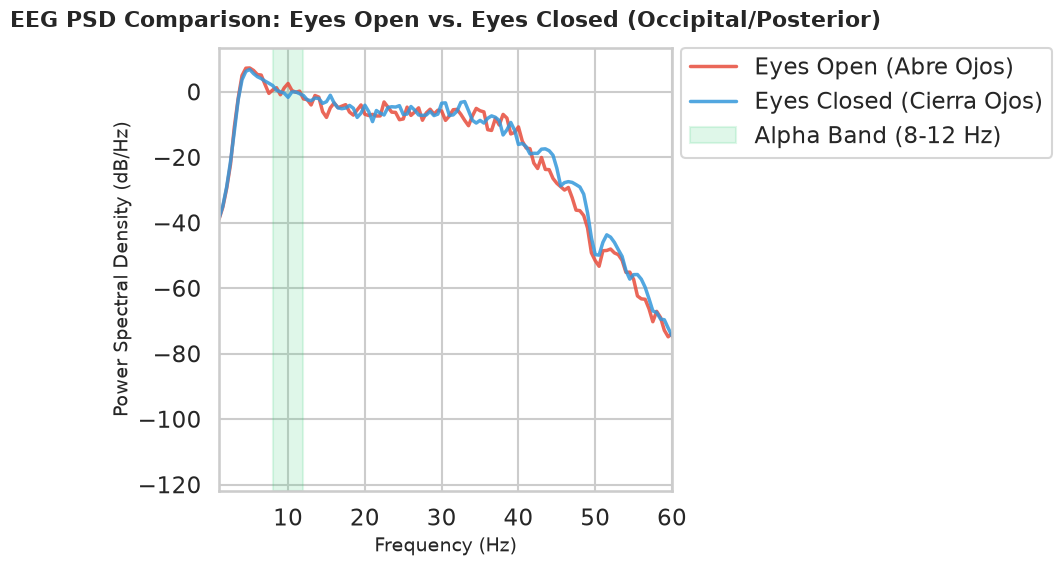

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import welch

# Ensure a clean plotting style
sns.set_theme(style="whitegrid", context="talk")

# -----------------------------------------------------------------
# 0. Define Channel Names and Labels Setup
# -----------------------------------------------------------------
channel_names = [
    "F3",
    "Fz",
    "F4",
    "C3",
    "Pz",
    "C4",
    "P3",
    "P4"
]

# Convert sample labels to a numpy array for easy masking
y = np.array(y)

# Select occipital/posterior channels (Using P3 and P4 as proxies from your list)
# If you have O1 and O2 in your raw data, update this list accordingly!
occipital_channels = ["P3", "P4"]
occipital_indices = [channel_names.index(
    ch) for ch in occipital_channels if ch in channel_names]

# -----------------------------------------------------------------
# 1. Compute PSD using Welch's Method for Open vs Closed
# -----------------------------------------------------------------
nperseg = min(2 * fs, X_filtered.shape[-1])

# Create boolean masks for labels
open_mask = (y == 'Abre Ojos')
closed_mask = (y == 'Cierra Ojos')

# Extract data subset per condition
# Assuming X_filtered shape is (trials, batches, channels, time) or similar.
# We slice along the trial/sample axis (axis 0)
X_open = X_filtered[open_mask]
X_closed = X_filtered[closed_mask]

# Compute Welch PSD for open eyes
freqs, psd_open_raw = welch(X_open, fs=fs, nperseg=nperseg, axis=-1)
# Average across trials, batches, and restrict to occipital channels
psd_open_avg = np.mean(psd_open_raw, axis=tuple(
    range(psd_open_raw.ndim - 2)))  # averages batch/trial dims
psd_open_occipital = np.mean(psd_open_avg[occipital_indices], axis=0)
psd_open_db = 10 * np.log10(psd_open_occipital)

# Compute Welch PSD for closed eyes
_, psd_closed_raw = welch(X_closed, fs=fs, nperseg=nperseg, axis=-1)
psd_closed_avg = np.mean(psd_closed_raw, axis=tuple(
    range(psd_closed_raw.ndim - 2)))
psd_closed_occipital = np.mean(psd_closed_avg[occipital_indices], axis=0)
psd_closed_db = 10 * np.log10(psd_closed_occipital)

# -----------------------------------------------------------------
# 2. Create Comparison Plot
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=100)

plt.plot(
    freqs,
    psd_open_db,
    label="Eyes Open (Abre Ojos)",
    color="#e74c3c",
    linewidth=2.5,
    alpha=0.85,
)

plt.plot(
    freqs,
    psd_closed_db,
    label="Eyes Closed (Cierra Ojos)",
    color="#3498db",
    linewidth=2.5,
    alpha=0.85,
)

# Highlight typical alpha band range (8 - 12 Hz) where occipital differences peak
plt.axvspan(
    8.0,
    12.0,
    color="#2ecc71",
    alpha=0.15,
    label="Alpha Band (8-12 Hz)",
)

# Custom formatting
plt.title("EEG PSD Comparison: Eyes Open vs. Eyes Closed (Occipital/Posterior)",
          fontsize=16, pad=15, weight="bold")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Power Spectral Density (dB/Hz)", fontsize=14)

# Restrict X-axis to focus on low-to-mid frequencies (up to 40 Hz)
plt.xlim(1, 60)

# Clean up layout
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()